In [1]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)
from sklearn.metrics import f1_score, accuracy_score
import os
import shutil
import gc

# 1. Configuration
class Config:
    MODELS = [
        "xlm-roberta-large", 
        "bert-base-multilingual-cased"
    ]
    MAX_LEN = 512
    BATCH_SIZE = 4
    GRAD_ACCUM = 8
    EPOCHS = 10
    LR = 1e-5
    OUTPUT_DIR = "/kaggle/working/"
    TRAIN_FILE = "/kaggle/input/datasets/samonwitasarker/telugu-xlm/train.csv"
    DEV_FILE = "/kaggle/input/datasets/samonwitasarker/telugu-xlm/dev.csv"
    TEST_FILE = "/kaggle/input/datasets/samonwitasarker/telugu-xlm/test.csv"
    
    LABEL_LIST = [
        'Formal', 'Informal', 'Optimistic', 'Pessimistic', 'Humorous', 
        'Serious', 'Inspiring', 'Authoritative', 'Persuasive'
    ]
    LABEL2ID = {label: i for i, label in enumerate(LABEL_LIST)}
    ID2LABEL = {i: label for i, label in enumerate(LABEL_LIST)}

# 2. Data Loading
def load_data(file_path, is_test=False):
    for enc in ['utf-8-sig', 'utf-8', 'latin-1', 'utf-16']:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"Successfully loaded {file_path} with {enc} encoding")
            df = df.dropna(subset=['ORIGINAL TRANSCRIPTS', 'CHANGE STYLE'])
            if 'STYLE' in df.columns and not is_test:
                df = df.dropna(subset=['STYLE'])
                df['label'] = df['STYLE'].map(Config.LABEL2ID)
                df = df.dropna(subset=['label'])
            # Put CHANGE STYLE first to prevent truncation of target features
            df['text'] = df['CHANGE STYLE'].fillna('') + " [SEP] " + df['ORIGINAL TRANSCRIPTS'].fillna('')
            return df
        except Exception as e:
            continue
    raise Exception(f"Could not load {file_path}")

# 3. Dataset Component
class TeluguStyleDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512, text_col='text'):
        self.texts = df[text_col].tolist()
        self.labels = df['label'].tolist() if 'label' in df.columns else None
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# 4. Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1": f1}

def train_and_predict(model_name, train_df, val_df, test_df, device):
    print(f"\n--- Training and predicting with {model_name} ---")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Custom format for this specific model's tokenizer
    def format_text(row):
        return str(row['CHANGE STYLE']) + f" {tokenizer.sep_token} " + str(row['ORIGINAL TRANSCRIPTS'])
    
    train_df['formatted_text'] = train_df.apply(format_text, axis=1)
    val_df['formatted_text'] = val_df.apply(format_text, axis=1)
    test_df['formatted_text'] = test_df.apply(format_text, axis=1)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=len(Config.LABEL_LIST),
        id2label=Config.ID2LABEL,
        label2id=Config.LABEL2ID
    ).to(device)

    train_dataset = TeluguStyleDataset(train_df, tokenizer, Config.MAX_LEN, text_col='formatted_text')
    val_dataset = TeluguStyleDataset(val_df, tokenizer, Config.MAX_LEN, text_col='formatted_text')
    test_dataset = TeluguStyleDataset(test_df, tokenizer, Config.MAX_LEN, text_col='formatted_text')

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        num_train_epochs=Config.EPOCHS,
        per_device_train_batch_size=Config.BATCH_SIZE,
        per_device_eval_batch_size=Config.BATCH_SIZE,
        gradient_accumulation_steps=Config.GRAD_ACCUM,
        learning_rate=Config.LR,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        label_smoothing_factor=0.1,
        save_only_model=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    
    # Prediction (return logits for ensembling)
    print(f"Generating test logits for {model_name}...")
    model.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(test_df), Config.BATCH_SIZE * 2): # Adjusted batch for inference
            batch_df = test_df.iloc[i : i + (Config.BATCH_SIZE * 2)]
            inputs = tokenizer(
                batch_df['formatted_text'].tolist(),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=Config.MAX_LEN
            ).to(device)
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu().numpy())
    
    res = np.concatenate(all_logits, axis=0)
    
    # Cleanup to save space
    del model
    del trainer
    torch.cuda.empty_cache()
    gc.collect()
    
    # Remove results directory if it exists to save space
    if os.path.exists(training_args.output_dir):
        print(f"Cleaning up {training_args.output_dir}...")
        shutil.rmtree(training_args.output_dir)
        
    return res

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load Data
    print("Loading data...")
    train_df = load_data(Config.TRAIN_FILE)
    val_df = load_data(Config.DEV_FILE)
    test_df = load_data(Config.TEST_FILE, is_test=True)

    # Train all models and collect logits
    ensemble_logits = []
    for model_name in Config.MODELS:
        logits = train_and_predict(model_name, train_df, val_df, test_df, device)
        ensemble_logits.append(logits)
    
    # 5. Ensemble: Simple Averaging of Logits
    print("\n--- Performing Ensemble ---")
    avg_logits = np.mean(ensemble_logits, axis=0)
    final_preds = avg_logits.argmax(-1)
    
    # 6. Final Submission CSV
    test_df['STYLE'] = [Config.ID2LABEL[p] for p in final_preds]
    submission_df = test_df[['ID', 'STYLE']]
    submission_df.to_csv("submission.csv", index=False, encoding='utf-8-sig')
    print("Inference complete. Ensemble results saved to submission.csv")

if __name__ == "__main__":
    main()


Using device: cuda
Loading data...
Successfully loaded /kaggle/input/datasets/samonwitasarker/telugu-xlm/train.csv with utf-8-sig encoding
Successfully loaded /kaggle/input/datasets/samonwitasarker/telugu-xlm/dev.csv with utf-8-sig encoding
Successfully loaded /kaggle/input/datasets/samonwitasarker/telugu-xlm/test.csv with utf-8-sig encoding

--- Training and predicting with xlm-roberta-large ---


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Generating test logits for bert-base-multilingual-cased...
Cleaning up ./results_bert-base-multilingual-cased...

--- Performing Ensemble ---
Inference complete. Ensemble results saved to submission.csv


🚀 Starting Manual Gold Evaluation...
Loading predictions from submission.csv.

✅ Final Results on Gold Dataset:
Accuracy: 0.2423
Macro F1: 0.2492

📝 Full Classification Report:
               precision    recall  f1-score   support

       Formal       0.19      0.22      0.20        36
     Informal       0.33      0.35      0.34        34
   Optimistic       0.38      0.36      0.37        33
  Pessimistic       0.29      0.40      0.33        20
     Humorous       0.38      0.27      0.31        30
      Serious       0.00      0.00      0.00        45
    Inspiring       0.30      0.24      0.27        37
Authoritative       0.15      0.23      0.18        30
   Persuasive       0.22      0.25      0.23        28

     accuracy                           0.24       293
    macro avg       0.25      0.26      0.25       293
 weighted avg       0.24      0.24      0.24       293



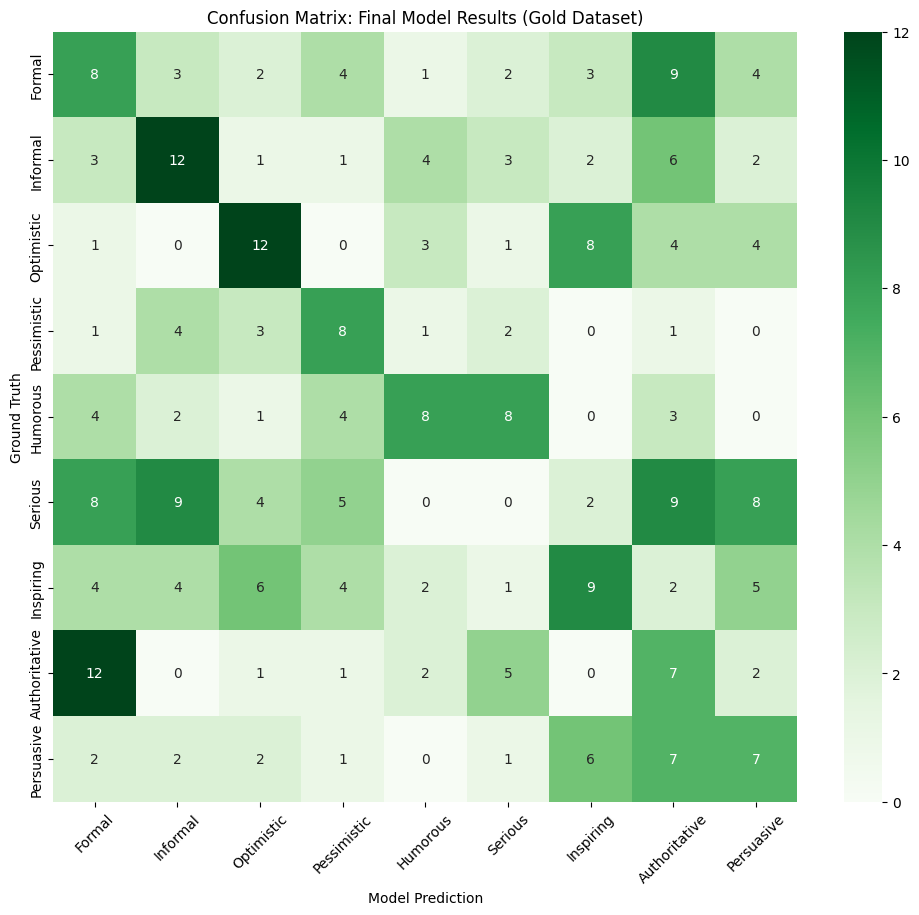

In [8]:
# --- MANUAL GOLD EVALUATION CELL ---
# Use this cell to evaluate the results at any time after running main()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("🚀 Starting Manual Gold Evaluation...")

# 1. Load Gold Labels
gold_labels_path = '/kaggle/input/datasets/samonwitasarker/telugu-xlm/PR_test_labels.xlsx - Sheet1.csv'
gold_labels_df = pd.read_csv(gold_labels_path)
gold_labels_df.columns = gold_labels_df.columns.str.strip()

# 2. Get Predictions (try from memory first, then from CSV)
if 'submission_df' in globals():
    print("Using submission_df from memory.")
    results_df = submission_df
elif os.path.exists('submission.csv'):
    print("Loading predictions from submission.csv.")
    results_df = pd.read_csv('submission.csv')
else:
    raise FileNotFoundError("No predictions found. Please run main() first or ensure submission.csv exists.")

# 3. Merge and Evaluate
gold_eval_df = results_df.merge(gold_labels_df, on='ID', suffixes=('_pred', '_true'))

y_true = [Config.LABEL2ID[str(l).strip()] for l in gold_eval_df['STYLE_true']]
y_pred = [Config.LABEL2ID[str(l).strip()] for l in gold_eval_df['STYLE_pred']]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\n✅ Final Results on Gold Dataset:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")

target_names = [label for label, idx in sorted(Config.LABEL2ID.items(), key=lambda item: item[1])]
print(f"\n📝 Full Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Final Model Results (Gold Dataset)')
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.xticks(rotation=45)
plt.show()